In [2]:
# =====================================
# Cleanup Old Outputs
# =====================================

import shutil
import os

paths_to_remove = [
    "/kaggle/working/figures",
    "/kaggle/working/logs",
    "/kaggle/working/models",
    "/kaggle/working/outputs",
    "/kaggle/working/baseline_confusion_matrix.png",
    "/kaggle/working/baseline_classification_report.txt",
    "/kaggle/working/training_history.csv",
    "/kaggle/working/training_log.txt"
]

for path in paths_to_remove:

    if os.path.exists(path):

        if os.path.isdir(path):
            shutil.rmtree(path)

        else:
            os.remove(path)

        print(f"Deleted: {path}")

print("Old outputs cleaned successfully.")

Old outputs cleaned successfully.


In [3]:
!pip install timm

In [4]:
#Imports + GPU Setup
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader

from torchvision import transforms

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

from sklearn.utils.class_weight import compute_class_weight

import timm

from tqdm import tqdm


# GPU Setup
device = torch.device("cuda")

print("Using device:", device)
print("GPU Name:", torch.cuda.get_device_name(0))

Using device: cuda
GPU Name: Tesla T4


In [5]:
# Output Directories

EXPERIMENT_NAME = "weighted_loss"

BASE_OUTPUT_DIR = f"/kaggle/working/outputs/{EXPERIMENT_NAME}"

FIGURE_DIR = os.path.join(BASE_OUTPUT_DIR, "figures")
REPORT_DIR = os.path.join(BASE_OUTPUT_DIR, "reports")
MODEL_DIR = os.path.join(BASE_OUTPUT_DIR, "models")
LOG_DIR = os.path.join(BASE_OUTPUT_DIR, "logs")

os.makedirs(FIGURE_DIR, exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

print("Output directories created successfully.")

Output directories created successfully.


In [6]:
#Dataset Loading

DATA_DIR = "/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000"
df = pd.read_csv(f"{DATA_DIR}/HAM10000_metadata.csv")

df.head()


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [7]:
#Image Path Mapping
image_dir_1 = f"{DATA_DIR}/HAM10000_images_part_1"
image_dir_2 = f"{DATA_DIR}/HAM10000_images_part_2"

image_paths = {}

for folder in [image_dir_1, image_dir_2]:
    for img in os.listdir(folder):
        image_id = img.split(".")[0]
        image_paths[image_id] = os.path.join(folder, img)

df["image_path"] = df["image_id"].map(image_paths)

In [8]:
#Label Encoding + Splits
label_encoder = LabelEncoder()

df["label"] = label_encoder.fit_transform(df["dx"])

train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    stratify=df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["label"],
    random_state=42
)

# Compute Class Weights

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_df["label"]),
    y=train_df["label"]
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float
).to(device)

print("Class Weights:")
print(class_weights)

# Class Names

class_names = label_encoder.classes_

print(class_names)

Class Weights:
tensor([ 4.3731,  2.7817,  1.3022, 12.3633,  1.2855,  0.2134, 10.1154],
       device='cuda:0')
['akiec' 'bcc' 'bkl' 'df' 'mel' 'nv' 'vasc']


In [9]:
#Transforms

IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [10]:
#Dataset Class

class HAM10000Dataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):

        row = self.dataframe.iloc[idx]

        image = Image.open(row["image_path"]).convert("RGB")

        label = row["label"]

        if self.transform:
            image = self.transform(image)

        return image, label

In [11]:
#Datasets + DataLoaders

train_dataset = HAM10000Dataset(
    train_df,
    transform=train_transform
)

val_dataset = HAM10000Dataset(
    val_df,
    transform=val_test_transform
)

test_dataset = HAM10000Dataset(
    test_df,
    transform=val_test_transform
)

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [12]:
#Load MobileViT

model = timm.create_model(
    "mobilevit_s",
    pretrained=True,
    num_classes=7
)

model = model.to(device)

print("Model loaded successfully")

model.safetensors:   0%|          | 0.00/22.4M [00:00<?, ?B/s]

Model loaded successfully


In [13]:
# Weighted Cross Entropy Loss

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

EPOCHS = 20

In [14]:
#Training Function

def train_one_epoch(model, loader, criterion, optimizer, device):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    loop = tqdm(loader, leave=True)

    for images, labels in loop:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = outputs.max(1)

        total += labels.size(0)

        correct += predicted.eq(labels).sum().item()

        loop.set_postfix(loss=loss.item())

    epoch_loss = running_loss / len(loader)

    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [15]:
#Validation Function

def validate(model, loader, criterion, device):

    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    all_labels = []
    all_preds = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = outputs.max(1)

            total += labels.size(0)

            correct += predicted.eq(labels).sum().item()

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())

    epoch_loss = running_loss / len(loader)

    epoch_acc = correct / total

    return epoch_loss, epoch_acc, all_labels, all_preds

In [16]:
#Main Training Loop
###
train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

best_val_acc = 0

for epoch in range(EPOCHS):

    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    train_bar = tqdm(train_loader)

    for images, labels in train_bar:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = outputs.max(1)

        total += labels.size(0)

        correct += predicted.eq(labels).sum().item()

        train_bar.set_postfix(
            loss=loss.item()
        )

    train_loss = running_loss / len(train_loader)

    train_acc = correct / total

    model.eval()

    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = outputs.max(1)

            val_total += labels.size(0)

            val_correct += predicted.eq(labels).sum().item()

    val_loss = val_loss / len(val_loader)

    val_acc = val_correct / val_total

    print(f"\nTrain Loss: {train_loss:.4f}")
    print(f"Train Accuracy: {train_acc:.4f}")

    print(f"\nValidation Loss: {val_loss:.4f}")
    print(f"Validation Accuracy: {val_acc:.4f}")

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    if val_acc > best_val_acc:

        best_val_acc = val_acc

        model_path = os.path.join(
            MODEL_DIR,
            "weighted_loss_best_model.pth"
        )

        torch.save(
            model.state_dict(),
            model_path
        )

        print(
            f"\nBest model saved with validation accuracy: {best_val_acc:.4f}"
        )


Epoch [1/20]


100%|██████████| 220/220 [01:12<00:00,  3.03it/s, loss=1.49] 



Train Loss: 1.5807
Train Accuracy: 0.5334

Validation Loss: 1.0863
Validation Accuracy: 0.7057

Best model saved with validation accuracy: 0.7057

Epoch [2/20]


100%|██████████| 220/220 [00:59<00:00,  3.71it/s, loss=2.33] 



Train Loss: 1.0092
Train Accuracy: 0.7238

Validation Loss: 0.8152
Validation Accuracy: 0.7750

Best model saved with validation accuracy: 0.7750

Epoch [3/20]


...


Train Loss: 0.2108
Train Accuracy: 0.8864

Validation Loss: 0.6142
Validation Accuracy: 0.8249

Epoch [19/20]


100%|██████████| 220/220 [01:00<00:00,  3.63it/s, loss=0.55]  



Train Loss: 0.2380
Train Accuracy: 0.8822

Validation Loss: 0.6503
Validation Accuracy: 0.8455

Best model saved with validation accuracy: 0.8455

Epoch [20/20]


100%|██████████| 220/220 [01:00<00:00,  3.63it/s, loss=1.27]  



Train Loss: 0.1766
Train Accuracy: 0.8967

Validation Loss: 0.6093
Validation Accuracy: 0.8648

Best model saved with validation accuracy: 0.8648


In [17]:
# Save Training History

history_df = pd.DataFrame({
    "epoch": list(range(1, EPOCHS + 1)),
    "train_loss": train_losses,
    "val_loss": val_losses,
    "train_accuracy": train_accuracies,
    "val_accuracy": val_accuracies
})

history_path = os.path.join(
    LOG_DIR,
    "weighted_loss_training_history.csv"
)

history_df.to_csv(history_path, index=False)

print("Training history saved successfully.")
print(f"Best Validation Accuracy: {best_val_acc:.4f}")

Training history saved successfully.
Best Validation Accuracy: 0.8648


Accuracy curve saved to: /kaggle/working/outputs/weighted_loss/figures/weighted_loss_accuracy_curve.png


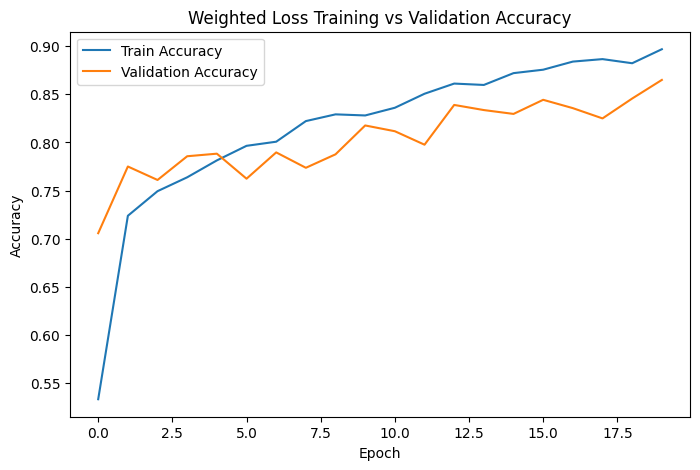

In [18]:
# =====================================
# Accuracy Curve
# =====================================

plt.figure(figsize=(8, 5))

plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Weighted Loss Training vs Validation Accuracy")

plt.legend()

curve_path = os.path.join(
    FIGURE_DIR,
    "weighted_loss_accuracy_curve.png"
)

plt.savefig(curve_path, bbox_inches='tight')

print(f"Accuracy curve saved to: {curve_path}")

plt.show()
plt.close()

In [19]:
test_loss, test_acc, test_labels, test_preds = validate(
    model,
    test_loader,
    criterion,
    device
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Test Loss: 0.7399
Test Accuracy: 0.8330


In [20]:
class_names = label_encoder.classes_

print(classification_report(
    test_labels,
    test_preds,
    target_names=class_names
))

              precision    recall  f1-score   support

       akiec       0.56      0.69      0.62        49
         bcc       0.71      0.84      0.77        77
         bkl       0.66      0.76      0.71       165
          df       0.43      0.71      0.53        17
         mel       0.59      0.57      0.58       167
          nv       0.95      0.90      0.92      1006
        vasc       0.83      0.86      0.84        22

    accuracy                           0.83      1503
   macro avg       0.67      0.76      0.71      1503
weighted avg       0.85      0.83      0.84      1503



Confusion matrix saved to: /kaggle/working/outputs/weighted_loss/figures/weighted_loss_confusion_matrix.png


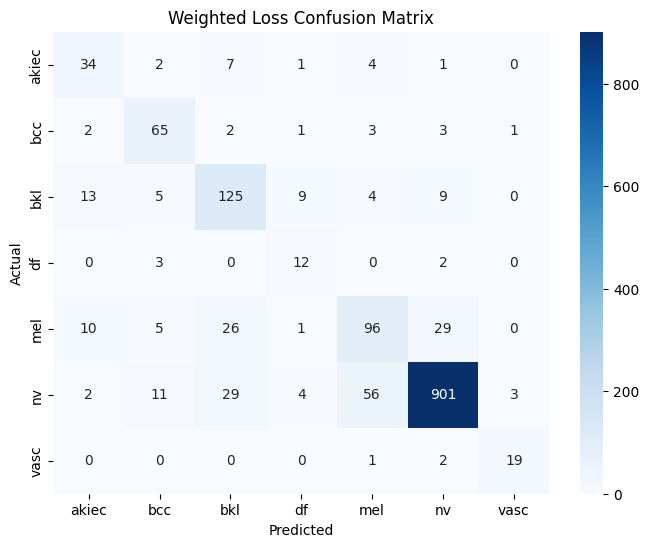

In [21]:
# Confusion Matrix

cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Weighted Loss Confusion Matrix")

save_path = os.path.join(
    FIGURE_DIR,
    "weighted_loss_confusion_matrix.png"
)

plt.savefig(save_path, bbox_inches='tight')

print(f"Confusion matrix saved to: {save_path}")

plt.show()
plt.close()

In [22]:
# Classification Report

report = classification_report(
    test_labels,
    test_preds,
    target_names=class_names
)

print(report)

report_path = os.path.join(
    REPORT_DIR,
    "weighted_loss_classification_report.txt"
)

with open(report_path, "w") as f:
    f.write(report)

print(f"Classification report saved to: {report_path}")

              precision    recall  f1-score   support

       akiec       0.56      0.69      0.62        49
         bcc       0.71      0.84      0.77        77
         bkl       0.66      0.76      0.71       165
          df       0.43      0.71      0.53        17
         mel       0.59      0.57      0.58       167
          nv       0.95      0.90      0.92      1006
        vasc       0.83      0.86      0.84        22

    accuracy                           0.83      1503
   macro avg       0.67      0.76      0.71      1503
weighted avg       0.85      0.83      0.84      1503

Classification report saved to: /kaggle/working/outputs/weighted_loss/reports/weighted_loss_classification_report.txt
